# Diabetes Prediction Challenge

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

from lightgbm import LGBMClassifier

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

In [3]:
train.shape, test.shape

((700000, 26), (300000, 25))

In [4]:
train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [5]:
train.isnull().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [6]:
df = pd.concat([train, test], axis=0).reset_index(drop=True)

### EDA - Exploratory Data Analysis

In [7]:
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [8]:
df.isnull().sum()

id                                         0
age                                        0
alcohol_consumption_per_week               0
physical_activity_minutes_per_week         0
diet_score                                 0
sleep_hours_per_day                        0
screen_time_hours_per_day                  0
bmi                                        0
waist_to_hip_ratio                         0
systolic_bp                                0
diastolic_bp                               0
heart_rate                                 0
cholesterol_total                          0
hdl_cholesterol                            0
ldl_cholesterol                            0
triglycerides                              0
gender                                     0
ethnicity                                  0
education_level                            0
income_level                               0
smoking_status                             0
employment_status                          0
family_his

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   id                                  1000000 non-null  int64  
 1   age                                 1000000 non-null  int64  
 2   alcohol_consumption_per_week        1000000 non-null  int64  
 3   physical_activity_minutes_per_week  1000000 non-null  int64  
 4   diet_score                          1000000 non-null  float64
 5   sleep_hours_per_day                 1000000 non-null  float64
 6   screen_time_hours_per_day           1000000 non-null  float64
 7   bmi                                 1000000 non-null  float64
 8   waist_to_hip_ratio                  1000000 non-null  float64
 9   systolic_bp                         1000000 non-null  int64  
 10  diastolic_bp                        1000000 non-null  int64  
 11  heart_rate  

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1000000.0,499999.500000,288675.278932,0.00,249999.75,499999.50,749999.25,999999.00
age,1000000.0,50.381533,11.741245,19.00,42.00,50.00,59.00,89.00
alcohol_consumption_per_week,1000000.0,2.077596,1.053658,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,1000000.0,83.866288,55.006110,1.00,49.00,72.00,100.00,748.00
diet_score,1000000.0,5.958338,1.468700,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,1000000.0,7.000878,0.905763,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,1000000.0,6.012296,2.034110,0.60,4.60,6.00,7.40,16.50
bmi,1000000.0,25.876851,2.870822,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,1000000.0,0.858838,0.038144,0.68,0.83,0.86,0.88,1.05
systolic_bp,1000000.0,116.318170,11.083525,91.00,108.00,116.00,124.00,170.00


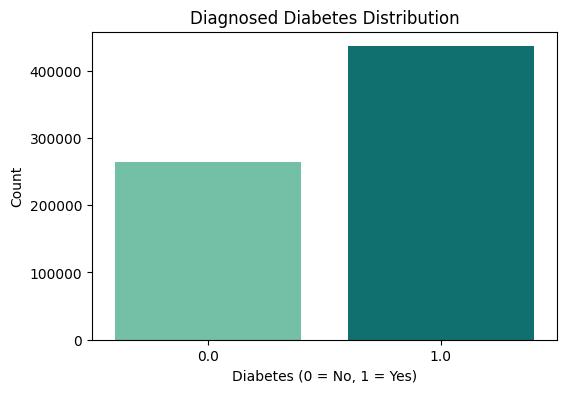

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x=df['diagnosed_diabetes'], palette=['MediumAquaMarine','Teal'])

plt.title('Diagnosed Diabetes Distribution')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.show()

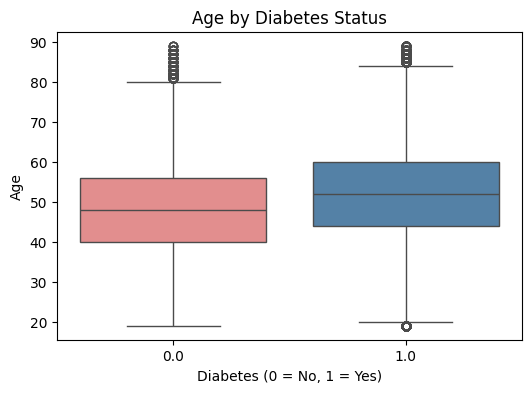

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(x='diagnosed_diabetes', y='age', data=df, palette=['lightcoral', 'steelblue'])

plt.title('Age by Diabetes Status')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Age')

plt.show()

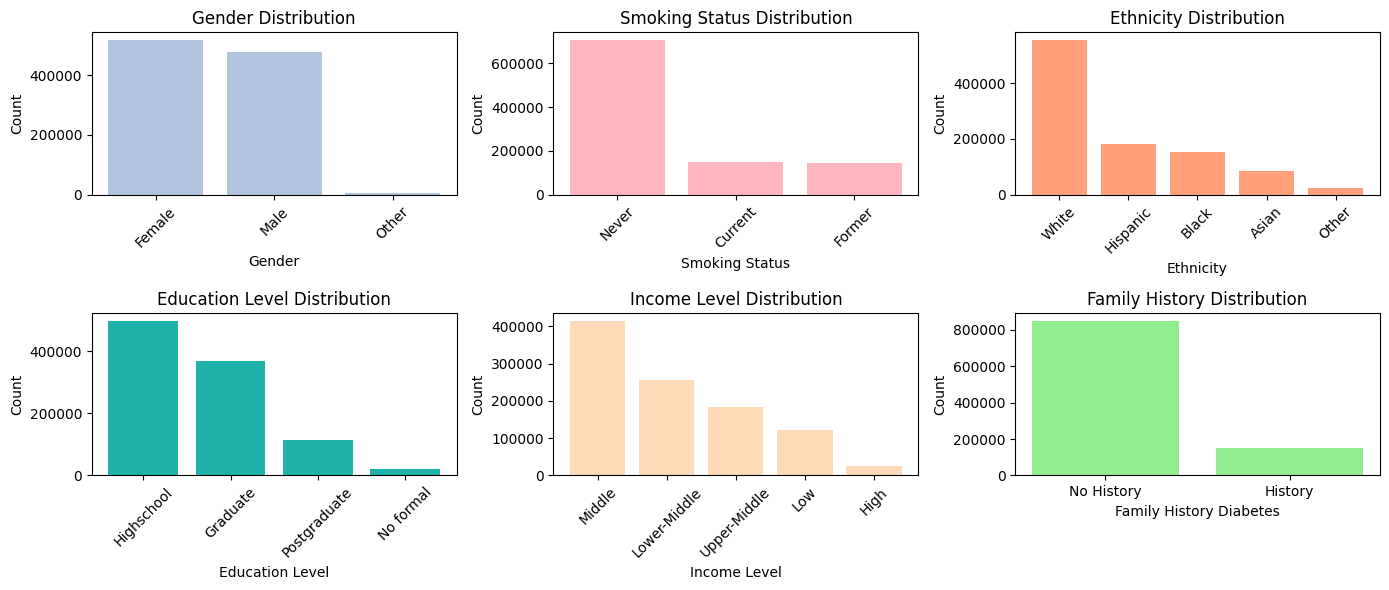

In [13]:
plt.figure(figsize=(14, 6))

plt.subplot(2, 3, 1)
plt.bar(df['gender'].value_counts().index, df['gender'].value_counts().values, color='LightSteelBlue')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
plt.bar(df['smoking_status'].value_counts().index, df['smoking_status'].value_counts().values, color='lightpink')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.title('Smoking Status Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 3)
plt.bar(df['ethnicity'].value_counts().index, df['ethnicity'].value_counts().values, color='LightSalmon')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.title('Ethnicity Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 4)
plt.bar(df['education_level'].value_counts().index, df['education_level'].value_counts().values, color='lightseagreen')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Education Level Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
plt.bar(df['income_level'].value_counts().index, df['income_level'].value_counts().values, color='peachpuff')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.title('Income Level Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
plt.bar(['No History', 'History'], [
    (df['family_history_diabetes'] == 0).sum(),
    (df['family_history_diabetes'] == 1).sum()], color='LightGreen')
plt.xlabel('Family History Diabetes')
plt.ylabel('Count')
plt.title('Family History Distribution')

plt.tight_layout()
plt.show()


### Feature Engineering

In [14]:
df['smoking']=df['smoking_status'].map({'Never':0,'Former':1,'Current':2})

In [15]:
df['education_level']=df['education_level'].map({'No formal':0,'Highschool':1,'Graduate':2,'Postgraduate':3})

In [16]:
df['income_level']=df['income_level'].map({'Low':0,'Lower-Middle':1,'Middle':2,'Upper-Middle':3})

In [17]:
df['employment_status']=df['employment_status'].map({'Student':0,'Employed':1,'Retired':2})

In [18]:
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})

In [19]:
df['activity_category'] = pd.cut(df['physical_activity_minutes_per_week'], bins=[-1, 30, 75, 150, 750],labels=['Sedentary', 'Low', 'Moderate', 'High'])

In [20]:
df['metabolic_score'] = ((df['bmi'] - df['bmi'].min()) / (df['bmi'].max() - df['bmi'].min()) * 50 +
                         (df['waist_to_hip_ratio'] - df['waist_to_hip_ratio'].min()) / 
                         (df['waist_to_hip_ratio'].max() - df['waist_to_hip_ratio'].min()) * 50)

df['good_diet'] = (df['diet_score'] >= 6).astype(int)

In [21]:
df['age_bmi_interaction'] = df['age'] * df['bmi'] / 100

In [22]:
df['age_activity_interaction'] = df['age'] * (df['physical_activity_minutes_per_week'] / 100)

In [23]:
df['bmi_bp_interaction'] = (df['bmi'] / 25) * (df['systolic_bp'] / 120)

In [24]:
df['bp_category'] = pd.cut(df['systolic_bp'], 
                            bins=[0, 120, 130, 140, 200],
                            labels=['Normal', 'Elevated', 'High1', 'High2'])

In [25]:
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']

In [26]:
df['ldl_hdl_ratio'] = df['ldl_cholesterol'] / (df['hdl_cholesterol'] + 1)

In [27]:
df['trig_hdl_ratio'] = df['triglycerides'] / (df['hdl_cholesterol'] + 1)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 37 columns):
 #   Column                              Non-Null Count    Dtype   
---  ------                              --------------    -----   
 0   id                                  1000000 non-null  int64   
 1   age                                 1000000 non-null  int64   
 2   alcohol_consumption_per_week        1000000 non-null  int64   
 3   physical_activity_minutes_per_week  1000000 non-null  int64   
 4   diet_score                          1000000 non-null  float64 
 5   sleep_hours_per_day                 1000000 non-null  float64 
 6   screen_time_hours_per_day           1000000 non-null  float64 
 7   bmi                                 1000000 non-null  float64 
 8   waist_to_hip_ratio                  1000000 non-null  float64 
 9   systolic_bp                         1000000 non-null  int64   
 10  diastolic_bp                        1000000 non-null  int64   
 11 

In [29]:
columns = [
    'family_history_diabetes',
    'age_bmi_interaction',
    'physical_activity_minutes_per_week',
    'age',
    'bmi_bp_interaction',
    'systolic_bp',
    'bmi',
    'ldl_cholesterol',
    'age_activity_interaction',
    'metabolic_score', #
    'trig_hdl_ratio',
    'ldl_hdl_ratio',
    'triglycerides',
    'cholesterol_total',
    'waist_to_hip_ratio',
    'ethnicity',
    'activity_category',
    'bp_category'
]

In [30]:
train_df = df[df['diagnosed_diabetes'].notna()]
test_df  = df[df['diagnosed_diabetes'].isna()]

In [31]:
x = train_df[columns]
y = train_df['diagnosed_diabetes']

In [32]:
x_final_test = test_df[columns]

In [33]:
x_all = pd.concat([x, x_final_test])
x_all = pd.get_dummies(x_all, drop_first=True)

In [34]:
x = x_all.iloc[:len(x)]
x_final_test = x_all.iloc[len(x):]

In [35]:
r=RandomForestClassifier()
g=GradientBoostingClassifier()

In [36]:
x_train,x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [37]:
r.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
tahmin_r=r.predict(x_test)

In [39]:
accuracy_score(tahmin_r, y_test)

0.6607214285714286

In [40]:
g.fit(x_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [41]:
tahmin_g=g.predict(x_test) 

In [42]:
accuracy_score(tahmin_g, y_test)

0.6692857142857143

In [43]:
roc_auc_score(y_test, tahmin_g)

0.6067986818369242

In [44]:
b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [46]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[20089 32540]
 [17548 69823]]
LogisticRegression()  modeli eğitiliyor!..
[[17485 35144]
 [12464 74907]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[24440 28189]
 [29375 57996]]
RandomForestClassifier()  modeli eğitiliyor!..


MemoryError: Unable to allocate 4.27 MiB for an array with shape (560000,) and data type int64

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

def advanced_classification_test(x, y):
    
    # Scaling
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    
    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(
        x_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Gelişmiş Modeller
    models = {
        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            random_state=42,
            verbose=-1
        ),
        "CatBoost": CatBoostClassifier(
            iterations=200,
            depth=6,
            learning_rate=0.05,
            random_state=42,
            verbose=0
        ),
        "Voting Ensemble": VotingClassifier(
            estimators=[
                ('xgb', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')),
                ('lgb', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),
                ('cat', CatBoostClassifier(iterations=100, random_state=42, verbose=0))
            ],
            voting='soft'
        )
    }
    
    results = []
    
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
        proba = model.predict_proba(x_test)[:, 1]
        
        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "Recall": recall_score(y_test, preds, zero_division=0),
            "F1": f1_score(y_test, preds, zero_division=0),
            "AUC": roc_auc_score(y_test, proba)
        })
    
    result = pd.DataFrame(results)
    result = result.sort_values(by="AUC", ascending=False).reset_index(drop=True)
    
    return result

result = advanced_classification_test(x, y)
print(result)

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(x, y)

In [ ]:
prediction= model.predict(x_test)

In [ ]:
prediction_final = model.predict(x_final_test)

In [ ]:
sonuc = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': prediction_final
})

In [ ]:
sonuc

In [ ]:
sonuc.to_csv('submission.csv', index=False)

In [ ]:
import joblib
joblib.dump(model, 'model.joblib')